Raw shape: (303, 352)
Metadata columns: ['Strain', 'Brain', 'Palp', 'Sensilla', 'Location', 'JODistance', 'ElectrodeLocation']
Total odour x cell response columns: 345
  Multi-odour-named columns found: 210
  ...of which empty (dropped): 210
  ...of which contain real data (KEPT): 0
  Kept for analysis (single-odour + any mixture cols with data): 135

Long-format shape (non-empty responses only): (3350, 11)

Cluster counts (rows in long format):
Cluster
Lateral    2883
Medial      436
NaN          31
Name: count, dtype: int64

Rows usable for JODistance analysis: 2537
Cluster
Lateral    2380
Medial      157
dtype: int64

Saved: sensilla_long_tidy.csv (JODistance analysis subset)
Saved: sensilla_long_all.csv (full long-format table)

Sensillum-level summary table: 159 unique sensilla
Cluster
Lateral    146
Medial      13
dtype: int64
Saved: sensillum_level_summary.csv

AVG SPIKE RESPONSE vs JO DISTANCE, per sensillum, weighted by NReadings
(Medial vs Lateral)

Medial (n_sensilla=13, tot

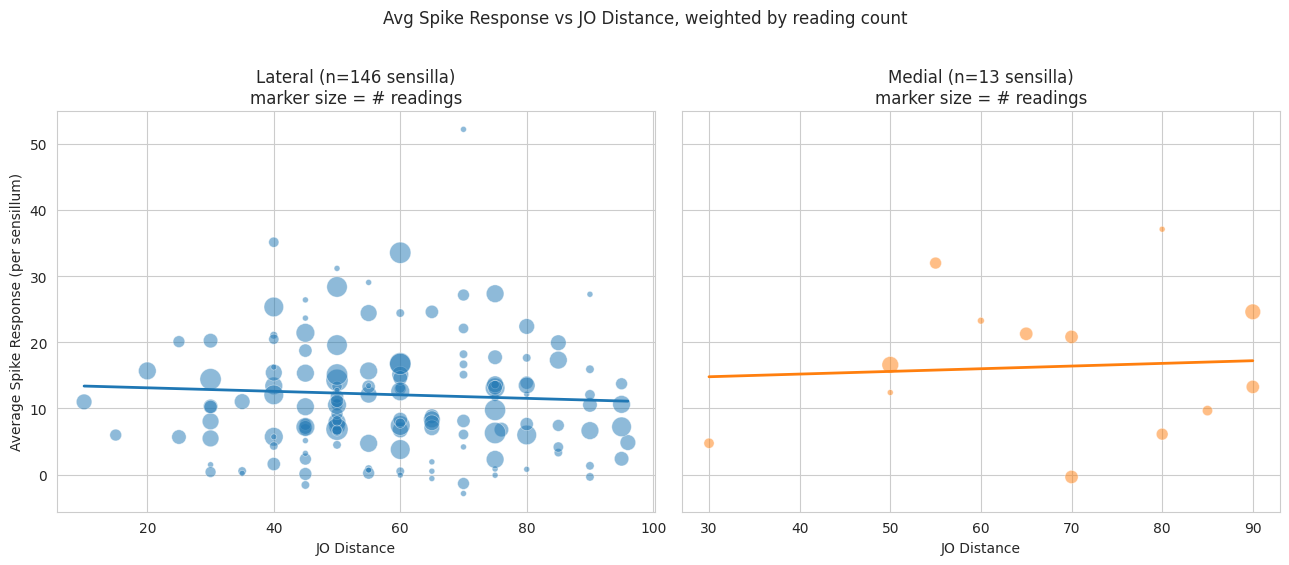


AVG SPIKE RESPONSE vs ElectrodeLocation, per sensillum, weighted by NReadings

Medial (n_sensilla=5):
  Unweighted Pearson r = -0.242, p = 0.6950
  Weighted   Pearson r = -0.261  (weight = NReadings per sensillum)
                            WLS Regression Results                            
Dep. Variable:       AvgSpikeResponse   R-squared:                       0.068
Model:                            WLS   Adj. R-squared:                 -0.242
Method:                 Least Squares   F-statistic:                    0.2198
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.671
Time:                        06:50:57   Log-Likelihood:                -17.592
No. Observations:                   5   AIC:                             39.18
Df Residuals:                       3   BIC:                             38.40
Df Model:                           1                                         
Covariance Type:            nonrobust                                     

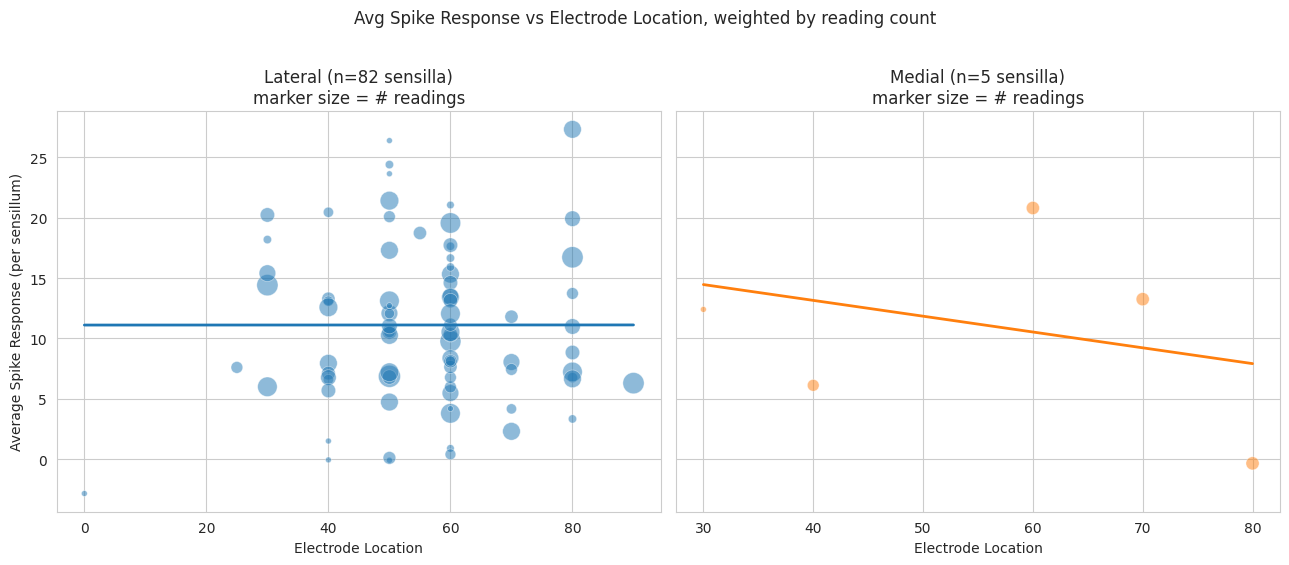


Reference: row-level (per-reading) SPIKE RESPONSE vs JO DISTANCE

Medial (n=157):
  Pearson  r = 0.021, p = 0.7932
  Spearman r = 0.056, p = 0.4898

Lateral (n=2380):
  Pearson  r = -0.021, p = 0.3038
  Spearman r = -0.041, p = 0.0445


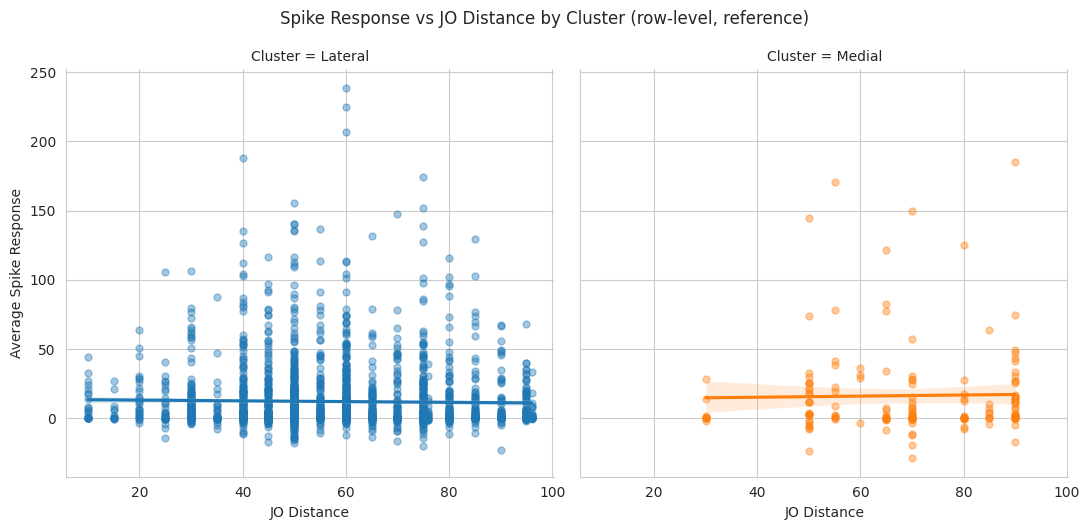

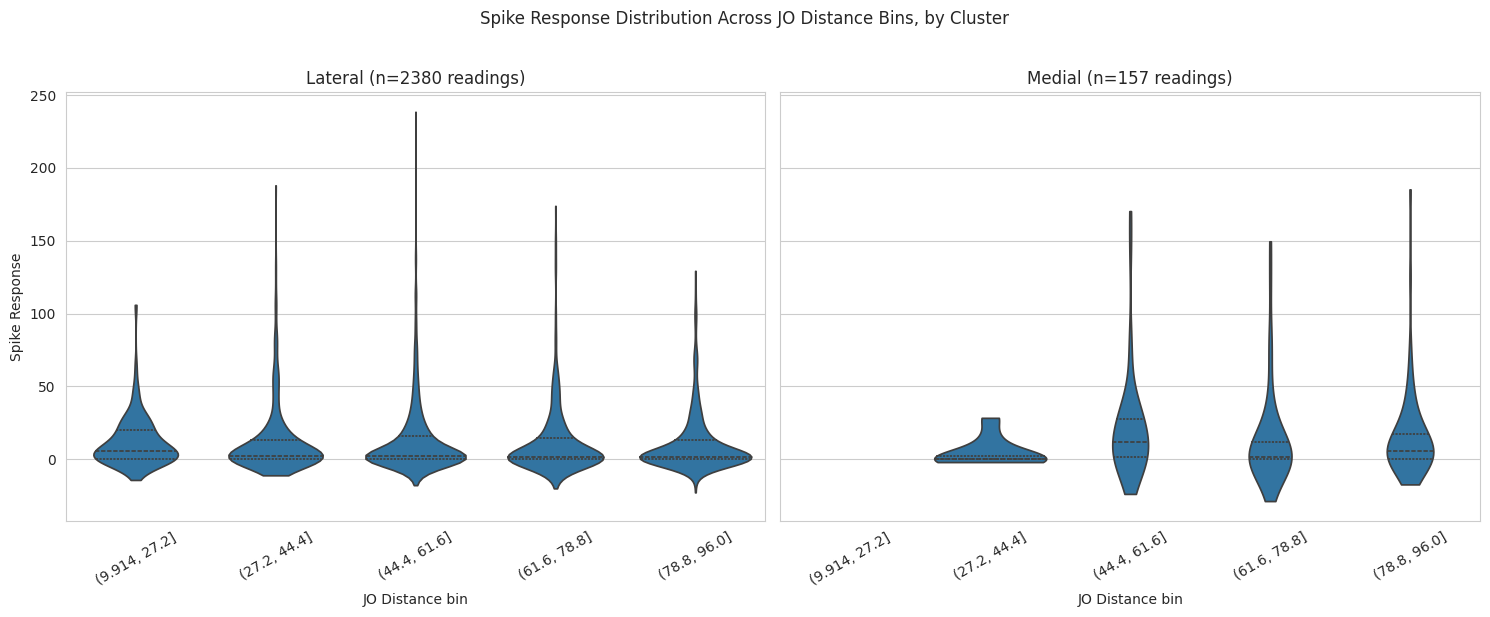


----------------------------------------------------------------------
Medial cluster — Mixed model: SpikeResponse ~ JODistance + Cell, random intercept by Strain
----------------------------------------------------------------------
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SpikeResponse
No. Observations: 157     Method:             REML         
No. Groups:       5       Scale:              1040.6626    
Min. group size:  9       Log-Likelihood:     -761.3981    
Max. group size:  97      Converged:          Yes          
Mean group size:  31.4                                     
-----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------
Intercept        9.460   13.649  0.693 0.488 -17.291 36.210
Cell[T.CpB]     -9.427    6.297 -1.497 0.134 -21.768  2.915
Cell[T.CpC]     -7.588    6.297 -1.205 0.228 -19.930  4.

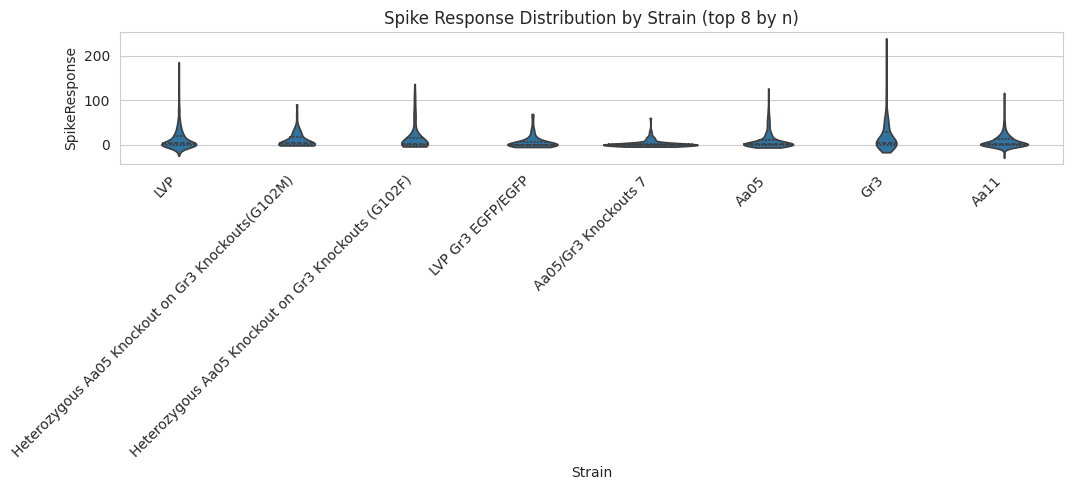


Mean SpikeResponse by Odour (top 15 by mean response, n>=5)
                 mean        std  count
Odour                                  
m5_BOL      46.761338  74.568938      6
m4_4MCYHOL  32.912132  47.146790      6
m6_BOL      21.913391  29.506860     36
m3_4MCYHOL  21.317716  29.859531    206
m4_BOL      19.651413  23.418477     15
m7_BOL      17.356920  22.797262    185
m6_1OCT3OL  16.769914  31.784067    120
m6_4MCYHOL  16.306852  27.353890    172
m0_CO2      14.353741  51.388560      9
m3_BOL      13.981174  21.684073     97
p_5CO2      13.722062  37.652763    173
m8_1OCT3OL  12.705887  28.318549    132
m5_4MCYHOL  12.242907  15.091119     86
m1_3MCYPON  11.674571  25.665511    171
m5_1OCT3OL  11.445604  24.354535     65


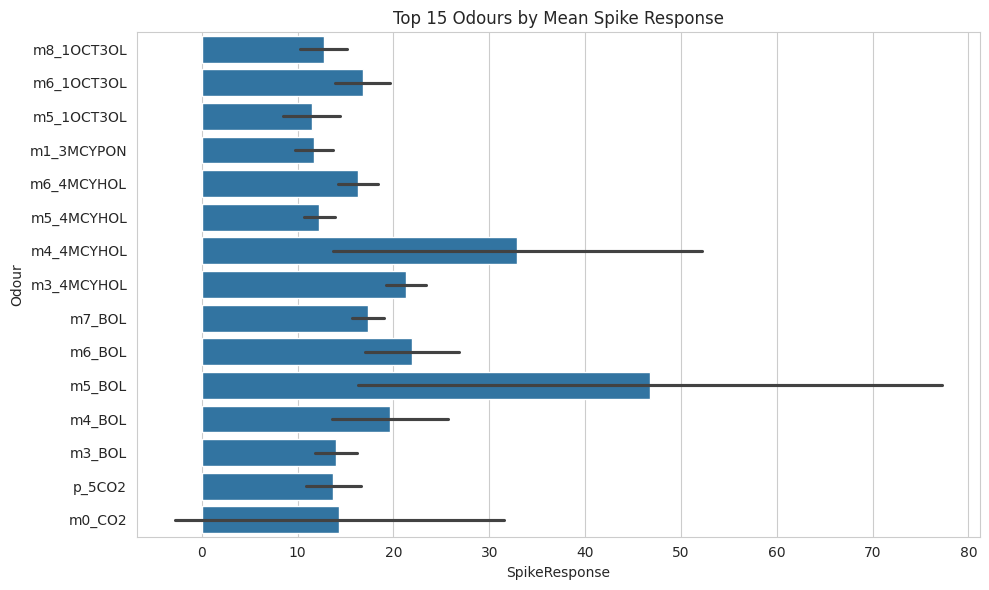


Mean SpikeResponse by Cell type and Cluster
                   mean        std  count
Cluster Cell                             
Lateral CpA    7.816876  21.940712    785
        CpB   17.158260  28.773480    798
        CpC   11.282746  18.111297    797
Medial  CpA   22.037779  42.627724     53
        CpB   12.538889  20.414616     52
        CpC   14.377566  31.835573     52


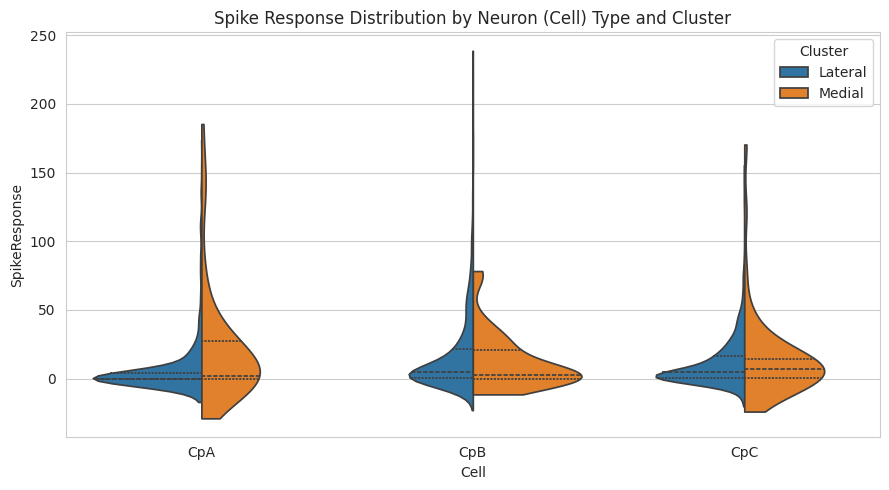

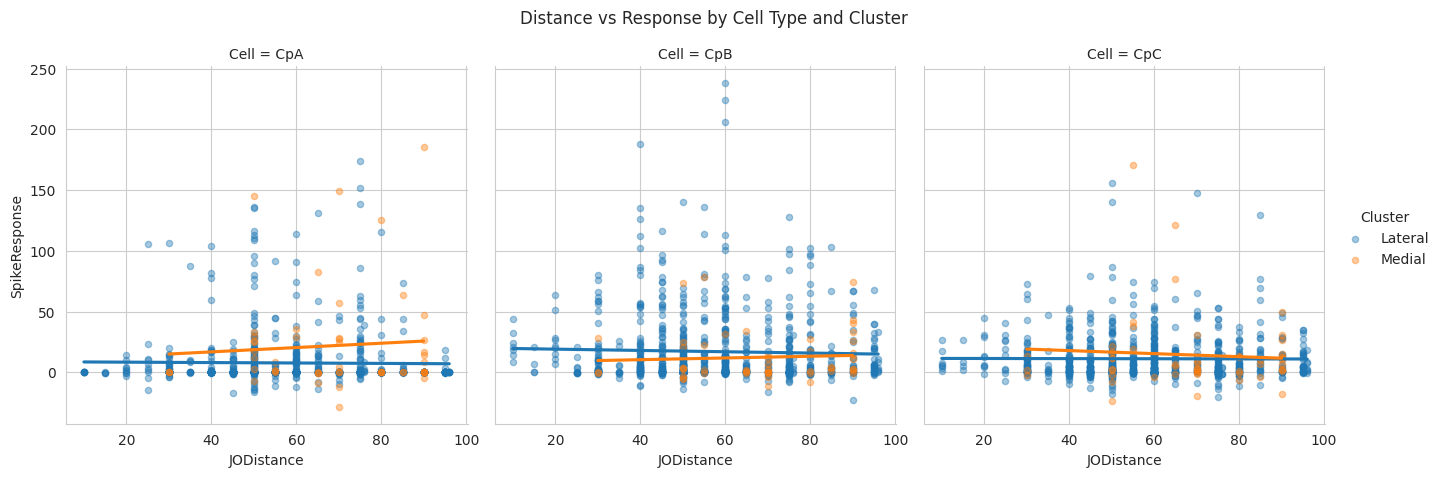

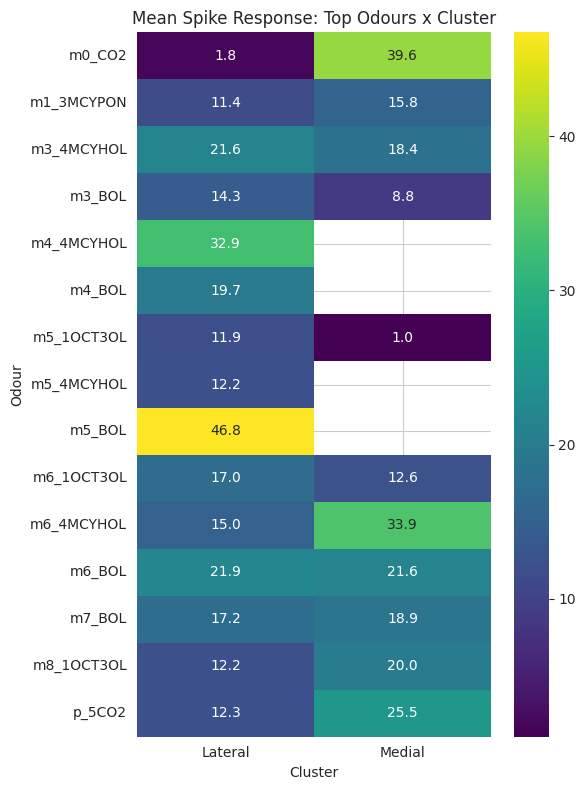

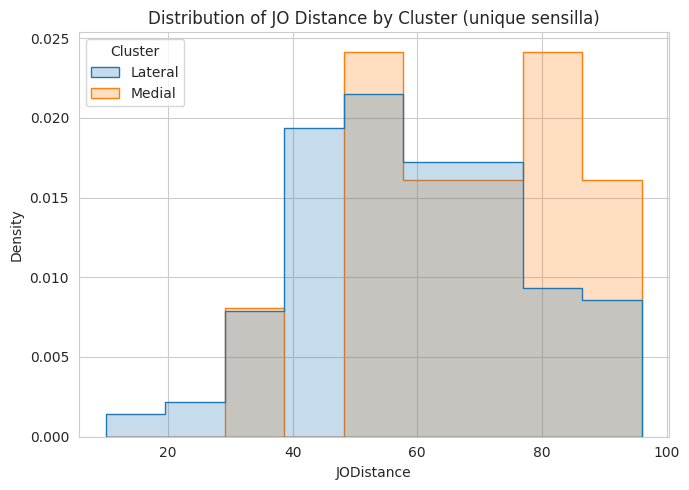


Done. All plots saved as PNGs in the working directory, and the tidy
long-format tables saved as sensilla_long_tidy.csv / sensilla_long_all.csv.


In [ ]:
# =============================================================
# Mosquito Maxillary Palp Sensilla — JO Distance vs Spike Response
# =============================================================
# Paste this whole script into a Colab cell. Only two things you may
# need to change are marked with "### CHANGE ME".
#
# What this script does:
#   1. Loads the messy wide-format Excel file
#   2. Reshapes it into tidy long format (one row per sensillum x odour x cell)
#   3. Cleans Location into Medial / Lateral clusters
#   4. Runs descriptive stats + correlations of JODistance vs SpikeResponse,
#      separately for Medial and Lateral
#   5. Fits mixed-effects models (accounting for Strain, Odour, Cell) per cluster
#   6. Produces a set of exploratory plots (distance-response, by strain,
#      by odour, by cell type, heatmaps)
#   7. Saves the tidy long-format table as a CSV for further work
# =============================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# -------------------------------------------------------------
# 1. LOAD
# -------------------------------------------------------------
FILE_PATH = "/content/Sensilla-Variability-Data_rows_2-1_COMPLETE.xlsx"  ### CHANGE ME if needed
### If working in Colab, either upload the file via the Files pane and use the
### path above, or mount Google Drive and point FILE_PATH there.

df = pd.read_excel(FILE_PATH, sheet_name="Sheet1", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location",
             "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

# -------------------------------------------------------------
# 1b. DROP EMPTY MULTI-ODOUR MIXTURE COLUMNS, KEEP ANY THAT HAVE DATA
# -------------------------------------------------------------
# Clean single-odour columns look like "m2_4MCYHOL_CpC" or "p_5CO2_CpA".
# Multi-odour mixture columns are auto-generated and look like
# "X_4methylcyclohexanol1_X0_1_1Octen3ol0_1_X0_1_CpB" -- they start with
# "X_" and/or contain the "_X0_1_" mixture-concentration marker joining two
# odour names. We only drop a mixture-named column if it is completely
# empty (no recorded readings) -- if a mixture column actually has data,
# it is KEPT, since dropping columns with real recordings would throw away
# information rather than just tidying naming noise.
mixture_named_cols = [c for c in all_response_cols
                       if c.startswith("X_") or "_X0_1_" in c]
mixture_has_data = [c for c in mixture_named_cols if df[c].notna().sum() > 0]
mixture_empty = [c for c in mixture_named_cols if c not in mixture_has_data]

response_cols = [c for c in all_response_cols if c not in mixture_empty]

print(f"Raw shape: {df.shape}")
print(f"Metadata columns: {meta_cols}")
print(f"Total odour x cell response columns: {len(all_response_cols)}")
print(f"  Multi-odour-named columns found: {len(mixture_named_cols)}")
print(f"  ...of which empty (dropped): {len(mixture_empty)}")
print(f"  ...of which contain real data (KEPT): {len(mixture_has_data)}")
if mixture_has_data:
    print("  Mixture columns kept because they have data:")
    for c in mixture_has_data:
        print(f"    {c}  (n={df[c].notna().sum()})")
print(f"  Kept for analysis (single-odour + any mixture cols with data): {len(response_cols)}")

# -------------------------------------------------------------
# 2. RESHAPE WIDE -> LONG
# -------------------------------------------------------------
# Every response column ends in _CpA / _CpB / _CpC (the three neurons
# housed in each capitate-peg sensillum). Everything before that is the
# odour/stimulus identity (some are clean e.g. "m3_S_LIM", others are
# auto-generated mixture names).
long_df = df.melt(id_vars=meta_cols, value_vars=response_cols,
                   var_name="RawCol", value_name="SpikeResponse")

long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df["IsMixture"] = long_df["Odour"].isin(
    [c.rsplit("_", 1)[0] for c in mixture_has_data]
)
long_df = long_df.drop(columns="RawCol")

# Drop rows with no recorded response (majority of the sparse matrix)
long_df = long_df.dropna(subset=["SpikeResponse"])

print(f"\nLong-format shape (non-empty responses only): {long_df.shape}")
if long_df["IsMixture"].any():
    print(f"  Of which from mixture-odour columns (kept because they had data): "
          f"{long_df['IsMixture'].sum()}")

# -------------------------------------------------------------
# 3. CLEAN Location -> Cluster (Medial / Lateral)
# -------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc):
        return np.nan
    loc = str(loc)
    if "Medial" in loc:
        return "Medial"
    elif "Lateral" in loc:
        return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

print("\nCluster counts (rows in long format):")
print(long_df["Cluster"].value_counts(dropna=False))

# -------------------------------------------------------------
# 4. FILTER to rows usable for the JODistance analysis
# -------------------------------------------------------------
analysis_df = long_df.dropna(subset=["JODistance", "SpikeResponse", "Cluster"]).copy()
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

print(f"\nRows usable for JODistance analysis: {analysis_df.shape[0]}")
print(analysis_df.groupby("Cluster").size())

# Give each physical sensillum a unique ID (Sensilla labels are already
# globally unique in this dataset, but this is defensive in case that
# changes).
analysis_df["SensillumID"] = (analysis_df["Strain"].astype(str) + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Save tidy table for further exploration in Colab
analysis_df.to_csv("sensilla_long_tidy.csv", index=False)
long_df.to_csv("sensilla_long_all.csv", index=False)  # includes rows w/o JODistance
print("\nSaved: sensilla_long_tidy.csv (JODistance analysis subset)")
print("Saved: sensilla_long_all.csv (full long-format table)")

# -------------------------------------------------------------
# 4b. WEIGHTING BY NUMBER OF READINGS PER SENSILLUM
# -------------------------------------------------------------
# Two different places "more readings = more weight" matters, and they are
# NOT the same thing:
#
#  (a) Row-level analyses (one row per odour x cell reading, e.g. the mixed
#      models below): a sensillum with 40 readings already contributes 40
#      rows, vs. 3 rows for a sparsely-sampled sensillum. That's already
#      proportional weighting by sample depth -- no extra weight column
#      is added there, since doing so would double-count (weight would
#      effectively become n^2).
#
#  (b) Sensillum-level analyses (one point per physical sensillum, since
#      JODistance/ElectrodeLocation are fixed per sensillum, not per
#      reading): here each sensillum collapses to ONE data point regardless
#      of how many readings it had, so we explicitly weight by NReadings
#      (precision weighting -- same logic as inverse-variance weighting in
#      meta-analysis: a mean based on 40 readings is more reliable than one
#      based on 3).
#
# View (b) is the main analysis for "average spike response vs distance
# from JO", since JODistance is a property of the sensillum, not of any
# single reading.

sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgSpikeResponse=("SpikeResponse", "mean"),
         NReadings=("SpikeResponse", "size"))
)
sensillum_summary.to_csv("sensillum_level_summary.csv", index=False)
print(f"\nSensillum-level summary table: {sensillum_summary.shape[0]} unique sensilla")
print(sensillum_summary.groupby("Cluster").size())
print("Saved: sensillum_level_summary.csv")


def weighted_pearson(x, y, w):
    """Weighted Pearson correlation (analytic weights)."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)


# ===============================================================
# 5. MAIN QUESTION: AVG SPIKE RESPONSE vs JODistance, per SENSILLUM,
#    weighted by number of readings, split by Cluster
# ===============================================================
print("\n" + "="*70)
print("AVG SPIKE RESPONSE vs JO DISTANCE, per sensillum, weighted by NReadings")
print("(Medial vs Lateral)")
print("="*70)

for cluster in ["Medial", "Lateral"]:
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    if len(sub) < 3:
        print(f"\n{cluster}: not enough sensilla ({len(sub)})")
        continue
    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgSpikeResponse"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgSpikeResponse"], sub["NReadings"])
    print(f"\n{cluster} (n_sensilla={len(sub)}, total readings={sub['NReadings'].sum()}):")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Weighted   Pearson r = {r_w:.3f}  (weight = NReadings per sensillum)")

    # Weighted least squares: AvgSpikeResponse ~ JODistance, weights =
    # NReadings. This is the statistically proper way to fit a trend line
    # where some points are more reliable (more readings) than others.
    try:
        wls_model = smf.wls("AvgSpikeResponse ~ JODistance", data=sub,
                             weights=sub["NReadings"]).fit()
        print(f"\n  Weighted least squares (WLS), weights = NReadings:")
        print(wls_model.summary())
    except Exception as e:
        print(f"  WLS failed: {e}")

# Scatter plot: one point per sensillum, marker size = NReadings (so you can
# SEE which points are more heavily sampled / more reliable), with a WLS
# regression line overlaid per cluster.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#1f77b4", "#ff7f0e"]):
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgSpikeResponse"],
               s=sub["NReadings"] * 6, alpha=0.5, color=color,
               edgecolor="white", linewidth=0.5)
    if len(sub) >= 3:
        try:
            wls_model = smf.wls("AvgSpikeResponse ~ JODistance", data=sub,
                                 weights=sub["NReadings"]).fit()
            xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
            pred = wls_model.predict(pd.DataFrame({"JODistance": xs}))
            ax.plot(xs, pred, color=color, linewidth=2)
        except Exception:
            pass
    ax.set_title(f"{cluster} (n={len(sub)} sensilla)\nmarker size = # readings")
    ax.set_xlabel("JO Distance")
axes[0].set_ylabel("Average Spike Response (per sensillum)")
fig.suptitle("Avg Spike Response vs JO Distance, weighted by reading count", y=1.02)
plt.tight_layout()
plt.savefig("plot_distance_vs_response_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------
# 5b. AVG SPIKE RESPONSE vs ElectrodeLocation, per sensillum, weighted
# -------------------------------------------------------------
# NOTE: per your instruction, we do NOT test JODistance vs ElectrodeLocation
# directly against each other (that comparison is intentionally skipped).
# ElectrodeLocation vs AvgSpikeResponse is a separate, valid comparison and
# is included below using the same weighted approach.
print("\n" + "="*70)
print("AVG SPIKE RESPONSE vs ElectrodeLocation, per sensillum, weighted by NReadings")
print("="*70)

el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])
for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 3:
        print(f"\n{cluster}: not enough sensilla with ElectrodeLocation ({len(sub)})")
        continue
    r_unw, p_unw = stats.pearsonr(sub["ElectrodeLocation"], sub["AvgSpikeResponse"])
    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgSpikeResponse"], sub["NReadings"])
    print(f"\n{cluster} (n_sensilla={len(sub)}):")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Weighted   Pearson r = {r_w:.3f}  (weight = NReadings per sensillum)")
    try:
        wls_el = smf.wls("AvgSpikeResponse ~ ElectrodeLocation", data=sub,
                          weights=sub["NReadings"]).fit()
        print(wls_el.summary())
    except Exception as e:
        print(f"  WLS failed: {e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#1f77b4", "#ff7f0e"]):
    sub = el_summary[el_summary["Cluster"] == cluster]
    ax.scatter(sub["ElectrodeLocation"], sub["AvgSpikeResponse"],
               s=sub["NReadings"] * 6, alpha=0.5, color=color,
               edgecolor="white", linewidth=0.5)
    if len(sub) >= 3:
        try:
            wls_el = smf.wls("AvgSpikeResponse ~ ElectrodeLocation", data=sub,
                              weights=sub["NReadings"]).fit()
            xs = np.linspace(sub["ElectrodeLocation"].min(), sub["ElectrodeLocation"].max(), 100)
            pred = wls_el.predict(pd.DataFrame({"ElectrodeLocation": xs}))
            ax.plot(xs, pred, color=color, linewidth=2)
        except Exception:
            pass
    ax.set_title(f"{cluster} (n={len(sub)} sensilla)\nmarker size = # readings")
    ax.set_xlabel("Electrode Location")
axes[0].set_ylabel("Average Spike Response (per sensillum)")
fig.suptitle("Avg Spike Response vs Electrode Location, weighted by reading count", y=1.02)
plt.tight_layout()
plt.savefig("plot_electrodeloc_vs_response_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------
# 5c. Row-level reference view (each reading counted once). Heavily-sampled
#     sensilla already contribute proportionally more rows here -- no extra
#     weight is applied, to avoid double-counting relative to 5/5b above.
# -------------------------------------------------------------
print("\n" + "="*70)
print("Reference: row-level (per-reading) SPIKE RESPONSE vs JO DISTANCE")
print("="*70)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster]
    if len(sub) < 3:
        print(f"\n{cluster}: not enough data ({len(sub)} rows)")
        continue
    pear_r, pear_p = stats.pearsonr(sub["JODistance"], sub["SpikeResponse"])
    spear_r, spear_p = stats.spearmanr(sub["JODistance"], sub["SpikeResponse"])
    print(f"\n{cluster} (n={len(sub)}):")
    print(f"  Pearson  r = {pear_r:.3f}, p = {pear_p:.4f}")
    print(f"  Spearman r = {spear_r:.3f}, p = {spear_p:.4f}")

# Scatter plot with regression line, faceted by cluster
g = sns.lmplot(data=analysis_df, x="JODistance", y="SpikeResponse",
               col="Cluster", hue="Cluster", height=5, aspect=1.1,
               scatter_kws={"alpha": 0.4, "s": 25}, ci=95)
g.set_axis_labels("JO Distance", "Average Spike Response")
g.fig.suptitle("Spike Response vs JO Distance by Cluster (row-level, reference)", y=1.05)
plt.savefig("plot_distance_vs_response_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------
# 5d. VIOLIN PLOT: SpikeResponse distribution across JODistance bins, by
#     Cluster. A correlation/regression only captures a linear trend in the
#     mean -- a violin lets you see whether the SHAPE of the response
#     distribution (spread, skew, bimodality) changes across distance bins,
#     which a single r or slope value can hide.
# -------------------------------------------------------------
analysis_df["JODistanceBin"] = pd.cut(analysis_df["JODistance"], bins=5)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = analysis_df[analysis_df["Cluster"] == cluster]
    sns.violinplot(data=sub, x="JODistanceBin", y="SpikeResponse",
                    ax=ax, cut=0, inner="quartile")
    ax.set_title(f"{cluster} (n={len(sub)} readings)")
    ax.set_xlabel("JO Distance bin")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Spike Response")
fig.suptitle("Spike Response Distribution Across JO Distance Bins, by Cluster", y=1.02)
plt.tight_layout()
plt.savefig("plot_violin_distance_bins_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------
# 5b. MIXED-EFFECTS MODELS (accounting for Strain and Odour), per cluster
# -------------------------------------------------------------
# Random intercept per Strain to account for repeated sampling within
# the same strain; Odour entered as fixed effect since you specifically
# want to know if it modulates the distance relationship. Cell (A/B/C)
# is also included since the three neurons differ systematically.
#
# NOTE: with many sparsely-sampled odours, the Odour fixed effect may
# have highly unstable coefficients. A simpler model without Odour is
# also fit as a robustness check.

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    if sub["Strain"].nunique() < 2 or len(sub) < 10:
        print(f"\n{cluster}: skipping mixed model (insufficient strain/sample variation)")
        continue

    print("\n" + "-"*70)
    print(f"{cluster} cluster — Mixed model: SpikeResponse ~ JODistance + Cell, "
          f"random intercept by Strain")
    print("-"*70)
    try:
        model = smf.mixedlm("SpikeResponse ~ JODistance + Cell",
                             data=sub, groups=sub["Strain"])
        result = model.fit(reml=True)
        print(result.summary())
    except Exception as e:
        print(f"Model failed to converge: {e}")

    print("\nSimple check — SpikeResponse ~ JODistance only, random intercept by Strain")
    try:
        model_simple = smf.mixedlm("SpikeResponse ~ JODistance",
                                    data=sub, groups=sub["Strain"])
        result_simple = model_simple.fit(reml=True)
        print(result_simple.summary())
    except Exception as e:
        print(f"Model failed to converge: {e}")

# -------------------------------------------------------------
# 5c. Does the Cluster itself (Medial vs Lateral) interact with distance?
# -------------------------------------------------------------
print("\n" + "-"*70)
print("Does the distance-response relationship differ between Medial and Lateral?")
print("-"*70)
try:
    inter_model = smf.mixedlm("SpikeResponse ~ JODistance * Cluster",
                               data=analysis_df, groups=analysis_df["Strain"])
    inter_result = inter_model.fit(reml=True)
    print(inter_result.summary())
except Exception as e:
    print(f"Interaction model failed: {e}")

# ===============================================================
# 6. SECONDARY / EXPLORATORY ANALYSES
# ===============================================================

# --- 6a. Mean spike response by Strain ---
print("\n" + "="*70)
print("Mean SpikeResponse by Strain (top 10 by sample size)")
print("="*70)
strain_summary = (analysis_df.groupby("Strain")["SpikeResponse"]
                   .agg(["mean", "std", "count"])
                   .sort_values("count", ascending=False))
print(strain_summary.head(10))

plt.figure(figsize=(11, 5))
top_strains = strain_summary.head(8).index
sns.violinplot(data=analysis_df[analysis_df["Strain"].isin(top_strains)],
               x="Strain", y="SpikeResponse", cut=0, inner="quartile")
plt.xticks(rotation=45, ha="right")
plt.title("Spike Response Distribution by Strain (top 8 by n)")
plt.tight_layout()
plt.savefig("plot_response_by_strain.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6b. Mean spike response by Odour (top responders) ---
print("\n" + "="*70)
print("Mean SpikeResponse by Odour (top 15 by mean response, n>=5)")
print("="*70)
odour_summary = (analysis_df.groupby("Odour")["SpikeResponse"]
                  .agg(["mean", "std", "count"]))
odour_summary = odour_summary[odour_summary["count"] >= 5].sort_values("mean", ascending=False)
print(odour_summary.head(15))

plt.figure(figsize=(10, 6))
top_odours = odour_summary.head(15).index
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)],
            y="Odour", x="SpikeResponse", errorbar="se")
plt.title("Top 15 Odours by Mean Spike Response")
plt.tight_layout()
plt.savefig("plot_top_odours.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6c. Spike response by Cell type (A/B/C), by cluster ---
print("\n" + "="*70)
print("Mean SpikeResponse by Cell type and Cluster")
print("="*70)
print(analysis_df.groupby(["Cluster", "Cell"])["SpikeResponse"].agg(["mean", "std", "count"]))

plt.figure(figsize=(9, 5))
sns.violinplot(data=analysis_df, x="Cell", y="SpikeResponse", hue="Cluster",
               split=True, cut=0, inner="quartile")
plt.title("Spike Response Distribution by Neuron (Cell) Type and Cluster")
plt.tight_layout()
plt.savefig("plot_response_by_cell_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6d. Does distance-response relationship differ by cell type? ---
g2 = sns.lmplot(data=analysis_df, x="JODistance", y="SpikeResponse",
                 col="Cell", hue="Cluster", height=4.5, aspect=1,
                 scatter_kws={"alpha": 0.4, "s": 20}, ci=None)
g2.fig.suptitle("Distance vs Response by Cell Type and Cluster", y=1.05)
plt.savefig("plot_distance_by_cell_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6e. Heatmap: mean response per Odour x Cluster (top odours only) ---
pivot = (analysis_df[analysis_df["Odour"].isin(top_odours)]
         .groupby(["Odour", "Cluster"])["SpikeResponse"].mean().unstack())
plt.figure(figsize=(6, 8))
sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".1f")
plt.title("Mean Spike Response: Top Odours x Cluster")
plt.tight_layout()
plt.savefig("plot_heatmap_odour_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6f. Distribution of JODistance by Cluster (sanity check on sampling) ---
plt.figure(figsize=(7, 5))
sns.histplot(data=analysis_df.drop_duplicates(subset=["Strain","Brain","Palp","Sensilla"]),
             x="JODistance", hue="Cluster", element="step", stat="density", common_norm=False)
plt.title("Distribution of JO Distance by Cluster (unique sensilla)")
plt.tight_layout()
plt.savefig("plot_jodistance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone. All plots saved as PNGs in the working directory, and the tidy")
print("long-format tables saved as sensilla_long_tidy.csv / sensilla_long_all.csv.")

Raw Matrix Shape: (303, 352)
Total Filtered Spike Columns Kept for Analysis: 135
Tidy Long-Format Shape (Recorded spikes only): (3350, 10)

  PHASE 4: SPATIAL MAPPING — INFLECTING SPIKE RATES BY JO DISTANCE

>>> Medial Cluster Spatial Profile (n = 13 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.146, p = 0.6342
  Precision Weighted r = 0.074 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.5754     11.609      1.169      0.267     -11.977      39.127
JODistance     0.0404      0.164      0.247      0.810      -0.320       0.401

>>> Lateral Cluster Spatial Profile (n = 146 Sensilla Hairs) <<<
  Unweighted Pearson r = -0.018, p = 0.8281
  Precision Weighted r = -0.067 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
         

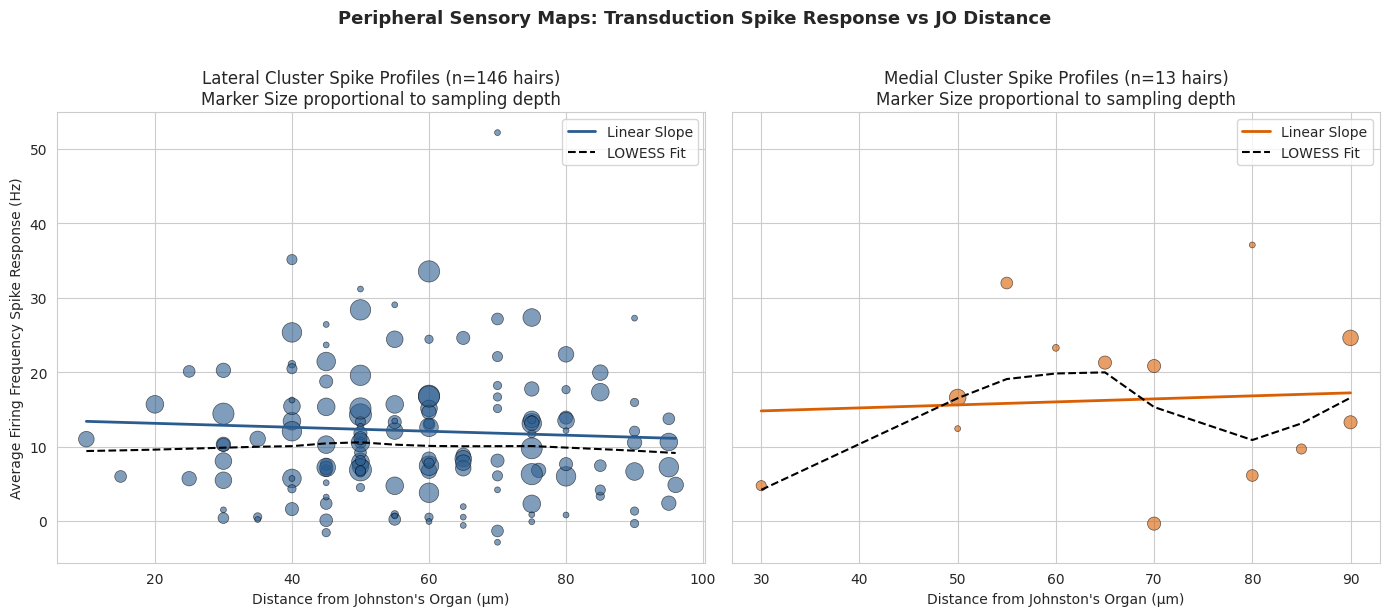


  PHASE 4b: TOTAL SPIKE INDUCTION VS ELECTRODE LOCATION COORDINATES

>>> Medial Coordinates Vector Evaluation (n = 5 Sensilla) <<<
  Unweighted Pearson r = -0.242, p = 0.6950
  Weighted Electrode Coordinate vs Spike Vector r = -0.261

  Weighted Least Squares (WLS) Coordinate Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            18.3980     17.884      1.029      0.379     -38.516      75.312
ElectrodeLocation    -0.1311      0.280     -0.469      0.671      -1.021       0.759

>>> Lateral Coordinates Vector Evaluation (n = 82 Sensilla) <<<
  Unweighted Pearson r = 0.049, p = 0.6651
  Weighted Electrode Coordinate vs Spike Vector r = 0.000

  Weighted Least Squares (WLS) Coordinate Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

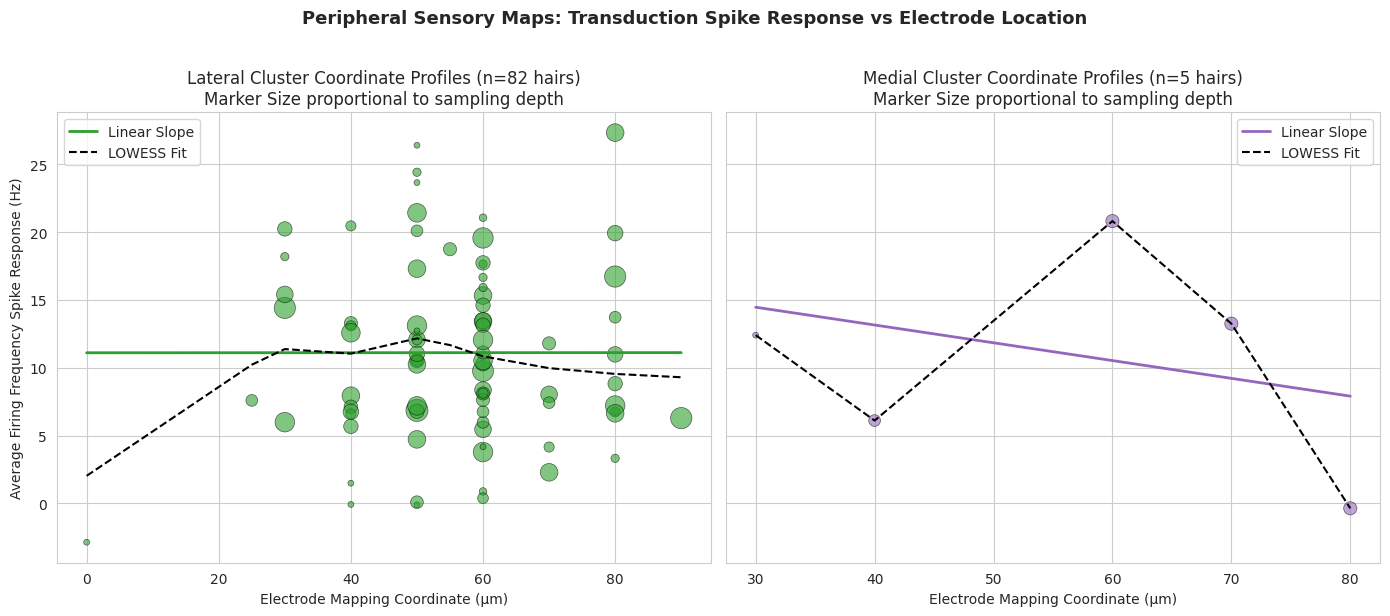

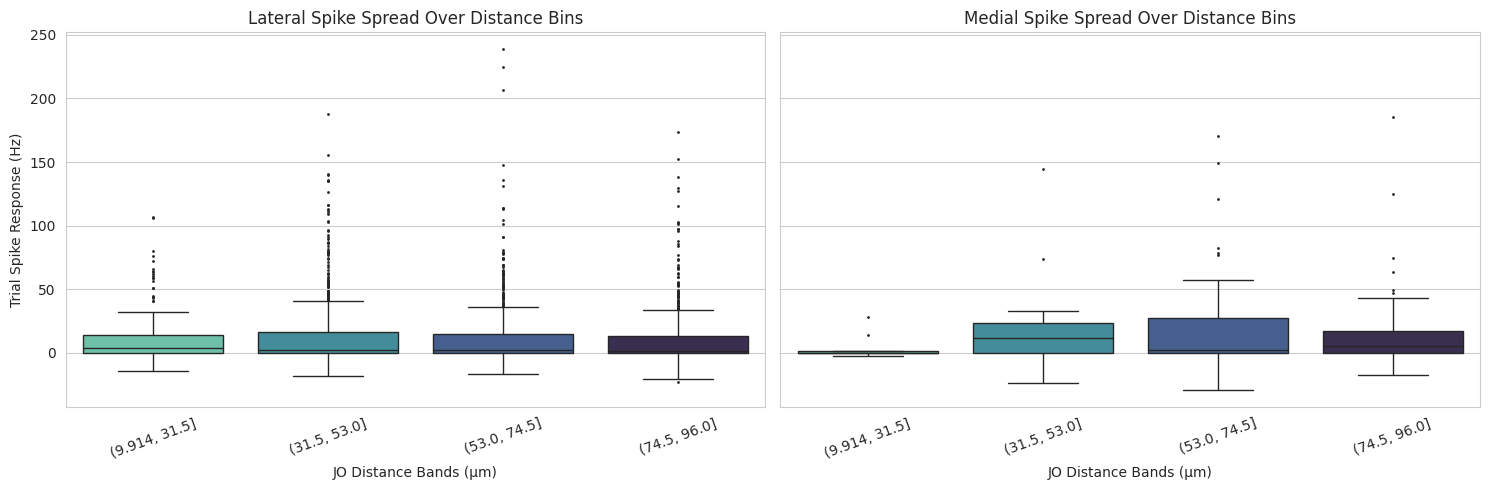


  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS

[LMM Output] Medial Array: SpikeResponse ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept     9.460   13.649   0.693  0.488  -17.291  36.210
Cell[T.CpB]  -9.427    6.297  -1.497  0.134  -21.768   2.915
Cell[T.CpC]  -7.588    6.297  -1.205  0.228  -19.930   4.753
JODistance    0.117    0.172   0.684  0.494   -0.219   0.453
Group Var    66.570    2.178                                

[LMM Output] Lateral Array: SpikeResponse ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept     9.351    2.507   3.730  0.000   4.438  14.265
Cell[T.CpB]   9.332    1.157   8.063  0.000   7.064  11.601
Cell[T.CpC]   3.454    1.158   2.983  0.003   1.184   5.723
JODistance   -0.035    0.027  -1.271  0.204  -0.088   0.019
Group Var    32.871    0.755                               

[Anatomical Interact

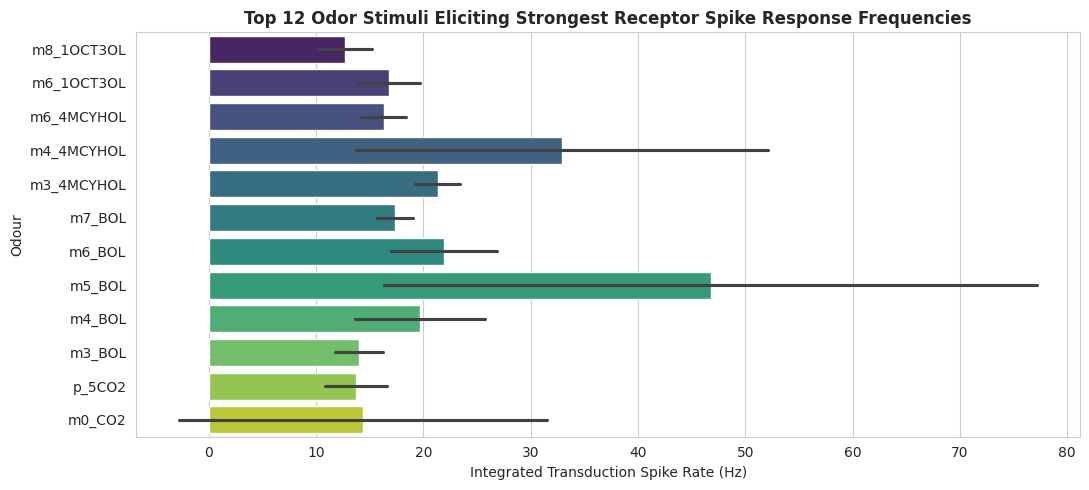

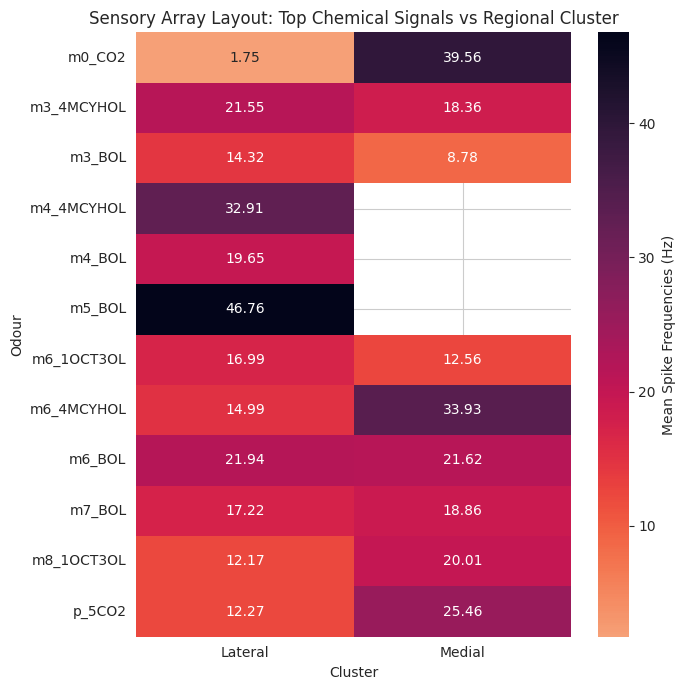


Pipeline Successfully Completed. Outputs saved cleanly to disk.


In [ ]:
# ==============================================================================
# Mosquito Maxillary Palp Sensilla — JO Distance & Electrode Location Deep Dive
# ==============================================================================
# Paste this entire script into your Colab cell.
# ==============================================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# ----------------------------------------------------------------
# 1. LOAD & RESHAPE DATA (SUPPORTING RAW EXCEL/CSV METRIC FLOWS)
# ----------------------------------------------------------------
FILE_PATH = "/content/Sensilla-Variability-Data_rows_2-1_COMPLETE.xlsx" ### Change if using alternative path

try:
    df = pd.read_excel(FILE_PATH, sheet_name="Sheet1", header=0)
except Exception:
    df = pd.read_csv("Sensilla-Variability-Data_rows_2-1_COMPLETE.csv", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

# Drop completely unrecorded multi-odor mixture columns while retaining those containing valid observations
mixture_named_cols = [c for c in all_response_cols if c.startswith("X_") or "_X0_1_" in c]
mixture_has_data = [c for c in mixture_named_cols if df[c].notna().sum() > 0]
mixture_empty = [c for c in mixture_named_cols if c not in mixture_has_data]
response_cols = [c for c in all_response_cols if c not in mixture_empty]

print(f"Raw Matrix Shape: {df.shape}")
print(f"Total Filtered Spike Columns Kept for Analysis: {len(response_cols)}")

# Melt wide matrix format to tidy long format
long_df = df.melt(id_vars=meta_cols, value_vars=response_cols,
                  var_name="RawCol", value_name="SpikeResponse")

# Extract neuronal pedigree (CpA, CpB, CpC) and stimulus labels
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol").dropna(subset=["SpikeResponse"])

print(f"Tidy Long-Format Shape (Recorded spikes only): {long_df.shape}")

# ----------------------------------------------------------------
# 2. ANATOMICAL CLUSTERING & CLEANING
# ----------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc).lower()
    if "medial" in loc: return "Medial"
    elif "lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# Filter down to rows containing spatial layout mappings
analysis_df = long_df.dropna(subset=["JODistance", "SpikeResponse", "Cluster"]).copy()
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Create unique tracking index per physical hair structure
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Export long table asset
analysis_df.to_csv("spike_sensilla_long_tidy.csv", index=False)

# ----------------------------------------------------------------
# 3. SENSILLUM-LEVEL AGGREGATION & BIAS CORRECTION (WEIGHTING)
# ----------------------------------------------------------------
# Collapse multi-odor metrics to unique physical nodes for spatial testing
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgSpikeResponse=("SpikeResponse", "mean"),
         MaxSpikeResponse=("SpikeResponse", "max"),
         NReadings=("SpikeResponse", "size"))
)
sensillum_summary.to_csv("spike_sensillum_level_summary.csv", index=False)

def weighted_pearson(x, y, w):
    """Analytic Weighted Pearson Correlation."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# ==============================================================================
# 4. PRIMARY ANALYSIS: SPIKE RATE VS JO DISTANCE
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4: SPATIAL MAPPING — INFLECTING SPIKE RATES BY JO DISTANCE")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} spatial modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgSpikeResponse"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgSpikeResponse"], sub["NReadings"])

    print(f"\n>>> {cluster} Cluster Spatial Profile (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")

    try:
        wls_model = smf.wls("AvgSpikeResponse ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_model.summary().tables[1])
    except Exception as e:
        print(f"  WLS Execution Error: {e}")

# Visualization: Weighted Bubble Matrix with Linear Trends & LOWESS curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#2b5c8f", "#d95f02"]):
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgSpikeResponse"],
               s=sub["NReadings"] * 6, alpha=0.6, color=color,
               edgecolor="black", linewidth=0.5)

    if len(sub) >= 4:
        # Fit Linear regression
        wls_model = smf.wls("AvgSpikeResponse ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        pred = wls_model.predict(pd.DataFrame({"JODistance": xs}))
        ax.plot(xs, pred, color=color, linewidth=2, label="Linear Slope")

        # Fit Local Non-Parametric Trend line
        lowess = sm.nonparametric.lowess(sub["AvgSpikeResponse"], sub["JODistance"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS Fit")

    ax.set_title(f"{cluster} Cluster Spike Profiles (n={len(sub)} hairs)\nMarker Size proportional to sampling depth")
    ax.set_xlabel("Distance from Johnston's Organ (μm)")
    ax.legend(frameon=True)

axes[0].set_ylabel("Average Firing Frequency Spike Response (Hz)")
fig.suptitle("Peripheral Sensory Maps: Transduction Spike Response vs JO Distance", y=1.02, fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("spike_analysis_jodistance_spatial.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================================
# 4b. SECONDARY GEOMETRIC CHECK: COORD LOCATION ANALYSIS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4b: TOTAL SPIKE INDUCTION VS ELECTRODE LOCATION COORDINATES")
print("="*80)

el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])
for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} Electrode Location modeling due to insufficient parameters.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["ElectrodeLocation"], sub["AvgSpikeResponse"])
    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgSpikeResponse"], sub["NReadings"])
    print(f"\n>>> {cluster} Coordinates Vector Evaluation (n = {len(sub)} Sensilla) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Weighted Electrode Coordinate vs Spike Vector r = {r_w:.3f}")
    try:
        wls_el = smf.wls("AvgSpikeResponse ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Coordinate Summary Table:")
        print(wls_el.summary().tables[1])
    except Exception as e: print(f"WLS coordinate evaluation faulted: {e}")

# Visualization 4b: Electrode Location Trend Matrix with LOWESS curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#2ca02c", "#9467bd"]):
    sub = el_summary[el_summary["Cluster"] == cluster]
    ax.scatter(sub["ElectrodeLocation"], sub["AvgSpikeResponse"],
               s=sub["NReadings"] * 6, alpha=0.6, color=color,
               edgecolor="black", linewidth=0.5)

    if len(sub) >= 4:
        # Fit Linear regression
        wls_el = smf.wls("AvgSpikeResponse ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["ElectrodeLocation"].min(), sub["ElectrodeLocation"].max(), 100)
        pred = wls_el.predict(pd.DataFrame({"ElectrodeLocation": xs}))
        ax.plot(xs, pred, color=color, linewidth=2, label="Linear Slope")

        # Fit Local Non-Parametric Trend line
        lowess = sm.nonparametric.lowess(sub["AvgSpikeResponse"], sub["ElectrodeLocation"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS Fit")

    ax.set_title(f"{cluster} Cluster Coordinate Profiles (n={len(sub)} hairs)\nMarker Size proportional to sampling depth")
    ax.set_xlabel("Electrode Mapping Coordinate (μm)")
    ax.legend(frameon=True)

axes[0].set_ylabel("Average Firing Frequency Spike Response (Hz)")
fig.suptitle("Peripheral Sensory Maps: Transduction Spike Response vs Electrode Location", y=1.02, fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("spike_analysis_electrodeloc_spatial.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# 4c. COARSE BOX-DIAGNOSTIC TRACKING ACROSS SPATIAL SECTORS
# ----------------------------------------------------------------
analysis_df["JODistanceBin"] = pd.cut(analysis_df["JODistance"], bins=4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = analysis_df[analysis_df["Cluster"] == cluster]
    sns.boxplot(data=sub, x="JODistanceBin", y="SpikeResponse", ax=ax, palette="mako_r", fliersize=1)
    ax.set_title(f"{cluster} Spike Spread Over Distance Bins")
    ax.set_xlabel("JO Distance Bands (μm)")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Trial Spike Response (Hz)")
plt.tight_layout()
plt.savefig("spike_variance_brackets.png", dpi=150)
plt.show()

# ==============================================================================
# 5. MIXED-EFFECTS MODELS: COMBINED ANATOMICAL CONTROLS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    if sub["Strain"].nunique() < 2 or len(sub) < 15:
        print(f"\nSkipping LMM analysis for {cluster} due to insufficient strain groupings.")
        continue

    print(f"\n[LMM Output] {cluster} Array: SpikeResponse ~ JODistance + Cell Lineage (Random Intercepts: Strain)")
    try:
        model = smf.mixedlm("SpikeResponse ~ JODistance + Cell", data=sub, groups=sub["Strain"])
        print(model.fit(reml=True).summary().tables[1])
    except Exception as e: print(f"LMM Convergence Failed: {e}")

print("\n[Anatomical Interaction Matrix] Evaluating Structural Convergence Spikes between Clusters:")
try:
    inter_model = smf.mixedlm("SpikeResponse ~ JODistance * Cluster", data=analysis_df, groups=analysis_df["Strain"])
    print(inter_model.fit(reml=True).summary())
except Exception as e: print(f"Structural cross interaction calculation failed: {e}")

# ==============================================================================
# 6. SENSORY TUNING CHARACTERISTICS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 6: RECEPTOR METRICS SUMMARY (ODOR SPECTRA AND PHENOTYPES)")
print("="*80)

# --- 6a. Mean Response Profiles per Odor ---
odour_summary = analysis_df.groupby("Odour")["SpikeResponse"].agg(["mean", "std", "count"])
# Target top 12 odors with largest positive frequency shifts
top_odours = odour_summary[odour_summary["count"] >= 5].sort_values("mean", ascending=False).head(12).index

plt.figure(figsize=(11, 5))
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)], y="Odour", x="SpikeResponse", errorbar="se", palette="viridis")
plt.title("Top 12 Odor Stimuli Eliciting Strongest Receptor Spike Response Frequencies", weight='bold')
plt.xlabel("Integrated Transduction Spike Rate (Hz)")
plt.tight_layout()
plt.savefig("spike_top_odors_profile.png", dpi=150)
plt.show()

# --- 6b. Spatial Receptor Distribution Maps (Heatmaps) ---
pivot = analysis_df[analysis_df["Odour"].isin(top_odours)].groupby(["Odour", "Cluster"])["SpikeResponse"].mean().unstack()
plt.figure(figsize=(7, 7))
sns.heatmap(pivot, cmap="rocket_r", center=pivot.stack().median(), annot=True, fmt=".2f", cbar_kws={'label': 'Mean Spike Frequencies (Hz)'})
plt.title("Sensory Array Layout: Top Chemical Signals vs Regional Cluster")
plt.tight_layout()
plt.savefig("spike_spatial_odor_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*80)
print("Pipeline Successfully Completed. Outputs saved cleanly to disk.")
print("="*80)